In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1

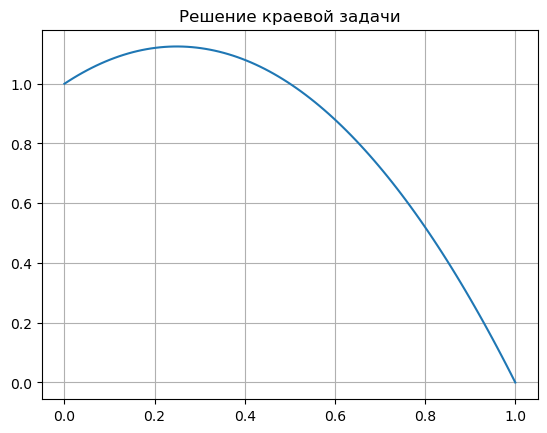

In [3]:
from scipy.integrate import solve_ivp

def func(t, y):
  A = np.array([[0,1],[-8, -(1-4*t)]])
  return A @ y + np.array([0,5])
T = 1
y0 = [0,1]
sol0 = solve_ivp(func, [T, 0], y0)
y1 = [0,0]
sol1 = solve_ivp(func, [T, 0], y1)
y0 = sol0.y
y1 = sol1.y
b1 = y0[1,-1]-y0[0,-1]
b2 = y1[1,-1]-y1[0,-1]
lam = 1-(-b1)/(b2-b1)
sol = solve_ivp(func, [T, 0], [0, lam], t_eval=np.linspace(1,0,100))

plt.plot(sol.t, sol.y[0])
plt.title('Решение краевой задачи')
plt.grid(True)

# 2

Численное значение y(π/2): 0.175
Точное значение y(π/2): 0.175
Численное значение dy/dx(π/2): 1.123
Точное значение dy/dx(π/2): 1.122


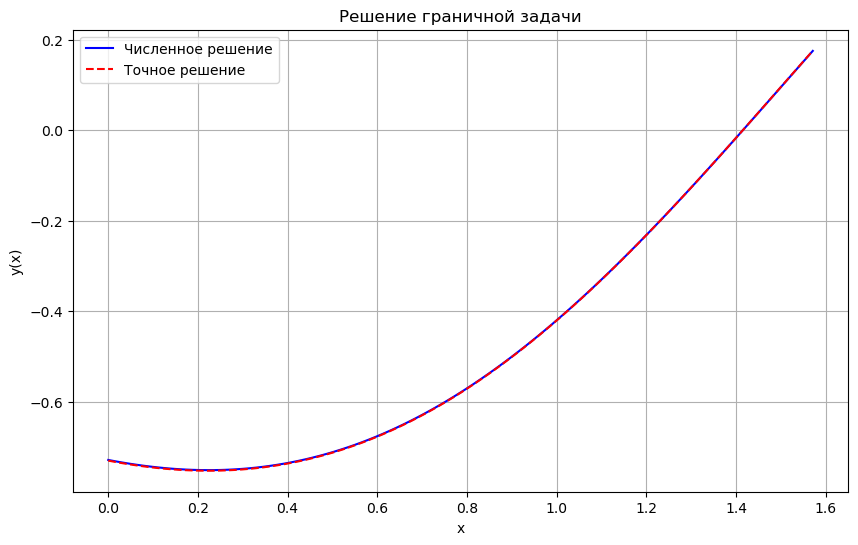

In [6]:
a = 0.0
b = np.pi / 2
N = 100
h = (b - a) / N
x = np.linspace(a, b, N+1)

A = np.zeros((N+1, N+1))
B = np.zeros(N+1)

A[0, 0] = -3*h - 1
A[0, 1] = 1
B[0] = 2*h

for i in range(1, N):
    A[i, i-1] = 1
    A[i, i] = -(2 - h**2)
    A[i, i+1] = 1
    B[i] = h**2 * x[i] * np.cos(x[i])

A[N, N-1] = 1
A[N, N] = -1 - 5*h
B[N] = -2*h

y = np.linalg.solve(A, B)

dy_dx_right = (-5*y[-1] + 2)

def exact_solution(x):
    return (-0.73 * np.cos(x) - 0.441 * np.sin(x) + 
            0.25 * (x**2 * np.sin(x) + x * np.cos(x)))

y_exact = exact_solution(x)

print(f"Численное значение y(π/2): {y[-1]:.3f}")
print(f"Точное значение y(π/2): 0.175")
print(f"Численное значение dy/dx(π/2): {dy_dx_right:.3f}")
print(f"Точное значение dy/dx(π/2): 1.122")

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', label='Численное решение')
plt.plot(x, y_exact, 'r--', label='Точное решение')
plt.xlabel('x')
plt.ylabel('y(x)')
plt.legend()
plt.grid(True)
plt.title('Решение граничной задачи')
plt.show()

# 3

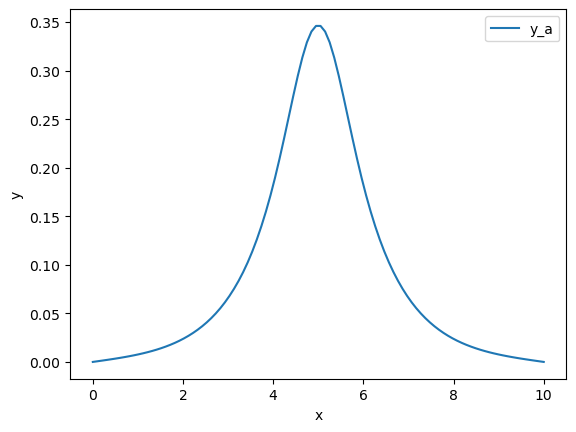

In [27]:
from scipy.integrate import solve_ivp

def func(t, y):
  return np.array([y[1],np.exp(y[0])-(1+np.exp(-3*(t-5)**2))])

def func2(t,y):
  return np.array([y[1],np.exp(sol.sol(t)[0])*y[0]])

s = 0.01
for i in range(10):
  y0 = [0,s]
  l = 10
  sol = solve_ivp(func, [0, l], y0, t_eval=np.linspace(0,10,10), dense_output=True)
  y1 = sol.y
  sol2 = solve_ivp(func2, [0, l], [0, 1], t_eval=np.linspace(0,10,10))
  y2 = sol2.y
  s = s-y1[0,-1]/y2[0,-1]

x_plot = np.linspace(0, 10, 100)
y_plot_a = sol.sol(x_plot)[0]
plt.plot(x_plot, y_plot_a, label='y_a')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# 4

Iteration 1: Residual = 9.999e-01
Iteration 2: Residual = 8.221e-02
Iteration 3: Residual = 7.780e-04
Iteration 4: Residual = 8.316e-08
Iteration 5: Residual = 9.068e-13


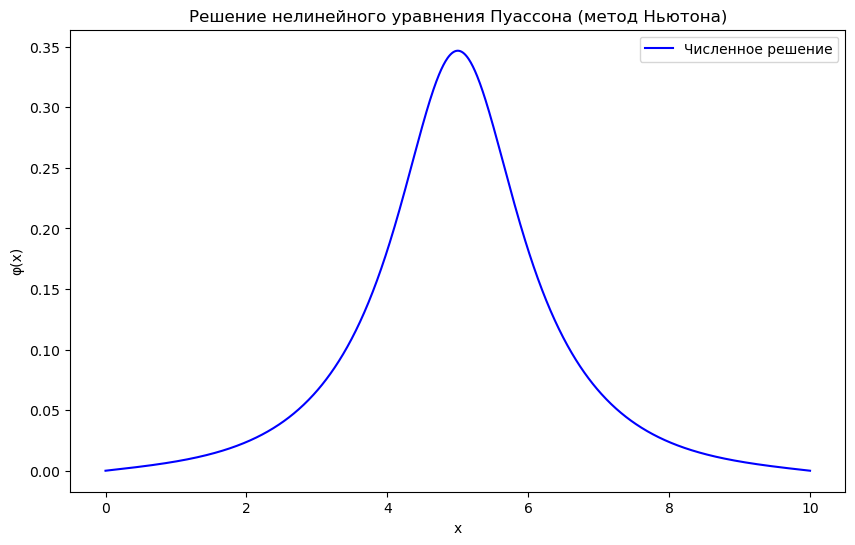

In [28]:
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

def n(x):
    return 1 + np.exp(-3*(x-5)**2)

def solve_nonlinear_poisson(N=1000, tol=1e-10, max_iter=20):
    x = np.linspace(0, 10, N)
    h = x[1] - x[0]
    phi = np.zeros(N)  

    for k in range(max_iter):
        main_diag = -2/h**2 - np.exp(phi[1:-1])
        lower_diag = np.ones(N-3)/h**2  
        upper_diag = np.ones(N-3)/h**2

        J = diags([lower_diag, main_diag, upper_diag], [-1, 0, 1], shape=(N-2, N-2), format='csr')

        F = (np.roll(phi, -1)[1:-1] - 2*phi[1:-1] + np.roll(phi, 1)[1:-1])/h**2 - np.exp(phi[1:-1]) + n(x[1:-1])

        delta = spsolve(J, -F)
        phi[1:-1] += delta

        residual = np.linalg.norm(F, np.inf)
        print(f"Iteration {k+1}: Residual = {residual:.3e}")
        if residual < tol:
            break

    return x, phi

x, phi = solve_nonlinear_poisson(N=1000, tol=1e-10)


plt.figure(figsize=(10, 6))
plt.plot(x, phi, 'b-', label='Численное решение')
plt.xlabel('x')
plt.ylabel('φ(x)')
plt.legend()
plt.title('Решение нелинейного уравнения Пуассона (метод Ньютона)')
plt.show()

# 5 п2

Итерация 1: Максимальная ошибка = 1.250e-01
Итерация 2: Максимальная ошибка = 8.363e-09
Сходимость достигнута.


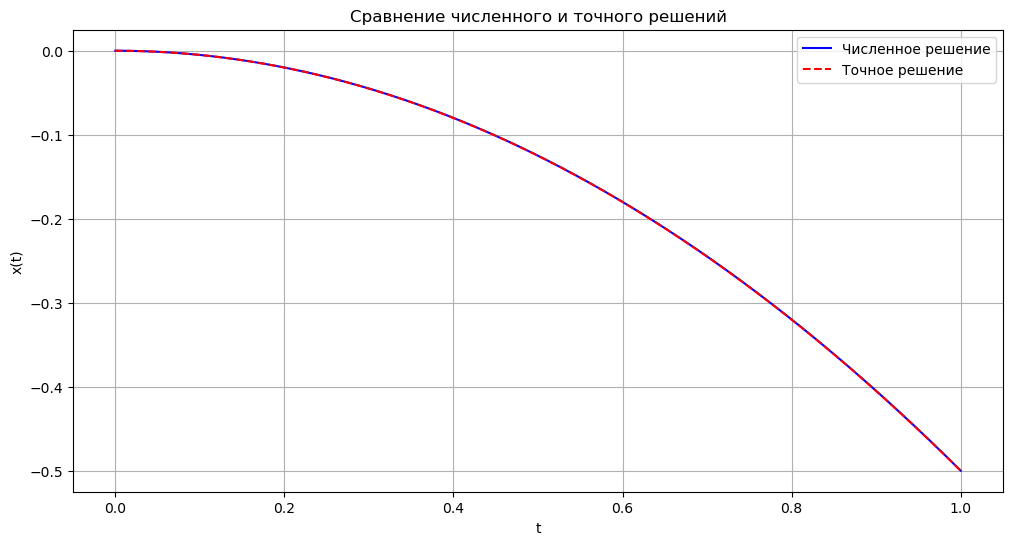

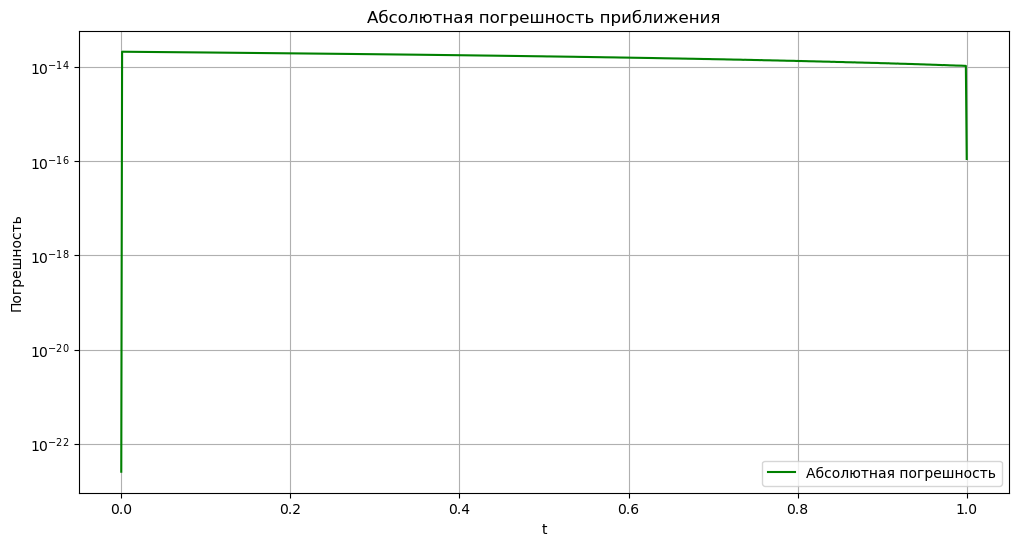

Максимальная погрешность: 2.096e-14


In [32]:
from scipy.integrate import solve_bvp

def exact_solution(t):
    return -0.5 * t**2


N = 50  
max_iter = 10 
tolerance = 1e-6  

t = np.linspace(0, 1, 1000)

x_prev = -0.5 * t  

for iter in range(max_iter):
    def fun(t, y):
        x, dxdt = y
        dydt = [dxdt, -((dxdt**2 + 1) / (1 + t**2))]
        return dydt
    
    def bc(ya, yb):
        return [ya[0], yb[0] + 0.5]
    
    sol = solve_bvp(fun, bc, t, np.vstack((x_prev, np.gradient(x_prev, t))))
    
    if not sol.success:
        print(f"Итерация {iter+1}: Ошибка решения")
        break
    
    x_new = sol.sol(t)[0]
    error = np.max(np.abs(x_new - x_prev))
    
    print(f"Итерация {iter+1}: Максимальная ошибка = {error:.3e}")
    
    if error < tolerance:
        print("Сходимость достигнута.")
        break
    
    x_prev = x_new.copy()

plt.figure(figsize=(12, 6))
plt.plot(t, x_new, 'b-', label='Численное решение')
plt.plot(t, exact_solution(t), 'r--', label='Точное решение')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.legend()
plt.grid(True)
plt.title('Сравнение численного и точного решений')
plt.show()

error = np.abs(x_new - exact_solution(t))
plt.figure(figsize=(12, 6))
plt.semilogy(t, error, 'g-', label='Абсолютная погрешность')
plt.xlabel('t')
plt.ylabel('Погрешность')
plt.legend()
plt.grid(True)
plt.title('Абсолютная погрешность приближения')
plt.show()

print(f"Максимальная погрешность: {np.max(error):.3e}")